# 02_baseline: ARnatomy (retrieval untuk Asisten AI)
Soal 4 (baseline) dan Soal 5 (pemeriksaan data leakage). Input: `data/processed/knowledge_base_bersih.csv` dan `data/processed/eval_set.csv` hasil `01_eda.ipynb`.

- **Baseline non-AI**: pencarian kata kunci (jumlah kata pertanyaan yang muncul di chunk).
- **Baseline ML/pengolahan**: retrieval TF-IDF + cosine similarity di dalam `Pipeline` scikit-learn.
- **Metrik**: Recall@1, Recall@3, Recall@5, MRR. Sebuah pertanyaan dianggap berhasil bila salah satu chunk kuncinya muncul di k teratas.

## Soal 4c. Muat data dan split evaluation set (dev vs test) sebelum memilih konfigurasi

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

kb = pd.read_csv('../data/processed/knowledge_base_bersih.csv')
ev = pd.read_csv('../data/processed/eval_set.csv')
ev['benar'] = ev['chunk_benar'].str.split()

# Split DULU: dev dipakai memilih konfigurasi, test hanya untuk laporan akhir
dev, test = train_test_split(ev, test_size=0.5, stratify=ev['sistem_organ'], random_state=42)
print('Chunk knowledge base:', len(kb))
print('Pertanyaan dev:', len(dev), '| test:', len(test))
print(test['sistem_organ'].value_counts())

Chunk knowledge base: 81
Pertanyaan dev: 17 | test: 18
sistem_organ
Sistem Pernapasan         9
Sistem Peredaran Darah    9
Name: count, dtype: int64


## Soal 4a-b. Baseline non-AI dan baseline TF-IDF dalam Pipeline

In [2]:
STOPWORD = ['apa', 'yang', 'dan', 'untuk', 'pada', 'berapa', 'bagaimana', 'mengapa', 'kenapa',
            'kapan', 'agar', 'dengan', 'adalah', 'atau', 'jika', 'itu', 'di', 'ke', 'dari', 'mana',
            'sih', 'saja', 'punya', 'namanya', 'ini', 'kalau', 'seperti', 'buat', 'gunanya',
            'lewat', 'sebelah', 'terjadi']

def normalisasi(teks):
    # preprocessing yang sama untuk chunk dan pertanyaan
    hasil = []
    for t in pd.Series(teks).astype(str):
        t = t.lower().replace('co2', 'karbon dioksida').replace('o2', 'oksigen')
        t = t.replace('±', 'sekitar ').replace('–', ' sampai ')
        hasil.append(' '.join(re.findall(r'\w+', t)))
    return hasil

def token(t):
    return set(w for w in normalisasi([t])[0].split() if w not in STOPWORD)

# ---------- Baseline non-AI: pencarian kata kunci ----------
class RetrieverKataKunci:
    def __init__(self, kolom):
        self.kolom = kolom
        self.tok_dok = [token(t) for t in kb[kolom]]
        self.pemecah_seri = np.random.RandomState(42).rand(len(kb)) * 1e-6  # skor seri diacak, tidak pilih kasih ke ID kecil
    def skor(self, q):
        tq = token(q)
        return np.array([len(tq & d) for d in self.tok_dok]) + self.pemecah_seri

# ---------- Baseline ML: TF-IDF di dalam Pipeline ----------
class RetrieverTfidf:
    def __init__(self, kolom, **param):
        self.pipe = Pipeline([('normalisasi', FunctionTransformer(normalisasi)),
                              ('tfidf', TfidfVectorizer(**param))])
        self.X_dok = self.pipe.fit_transform(kb[kolom])   # fit HANYA pada dokumen knowledge base
    def skor(self, q):
        return cosine_similarity(self.pipe.transform([q]), self.X_dok)[0]

def evaluasi(retriever, data):
    peringkat, top3 = [], []
    for q, benar in zip(data['pertanyaan'], data['benar']):
        s = retriever.skor(q)
        urut = [i for i in np.argsort(-s) if s[i] > 1e-5]
        ids = list(kb['id_chunk'].iloc[urut])
        pos = [ids.index(b) + 1 for b in benar if b in ids]
        peringkat.append(min(pos) if pos else np.inf)
        top3.append(ids[:3])
    r = np.array(peringkat)
    metrik = {'Recall@1': (r <= 1).mean(), 'Recall@3': (r <= 3).mean(),
              'Recall@5': (r <= 5).mean(), 'MRR': (1 / r).mean()}
    return metrik, r, top3

In [3]:
kandidat = {
    'Kata kunci (non-AI)':           RetrieverKataKunci('teks_bersih'),
    'Kata kunci + header':           RetrieverKataKunci('teks_kb'),
    'TF-IDF kata':                   RetrieverTfidf('teks_bersih', stop_words=STOPWORD),
    'TF-IDF kata + header':          RetrieverTfidf('teks_kb', stop_words=STOPWORD),
    'TF-IDF char n-gram + header':   RetrieverTfidf('teks_kb', analyzer='char_wb', ngram_range=(3, 5)),
}

# Pemilihan konfigurasi hanya berdasarkan DEV
hasil_dev = pd.DataFrame({n: evaluasi(r, dev)[0] for n, r in kandidat.items()}).T.round(3)
print('Hasil pada DEV set:')
print(hasil_dev.sort_values('MRR', ascending=False).to_string())

Hasil pada DEV set:
                             Recall@1  Recall@3  Recall@5    MRR
TF-IDF kata + header            0.706     0.824     0.824  0.777
Kata kunci + header             0.706     0.824     0.824  0.769
TF-IDF char n-gram + header     0.706     0.765     0.882  0.765
TF-IDF kata                     0.647     0.765     0.824  0.717
Kata kunci (non-AI)             0.647     0.706     0.824  0.713


TABEL PERBANDINGAN BASELINE
                             Recall@1 (test)  Recall@3 (test)  Recall@5 (test)  MRR (test)  MRR (35 soal)
Kata kunci (non-AI)                    0.722            0.944            0.944       0.838          0.777
Kata kunci + header                    0.667            1.000            1.000       0.833          0.802
TF-IDF kata                            0.778            0.944            0.944       0.866          0.794
TF-IDF kata + header                   0.611            0.833            0.944       0.759          0.768
TF-IDF char n-gram + header            0.722            0.944            0.944       0.843          0.805


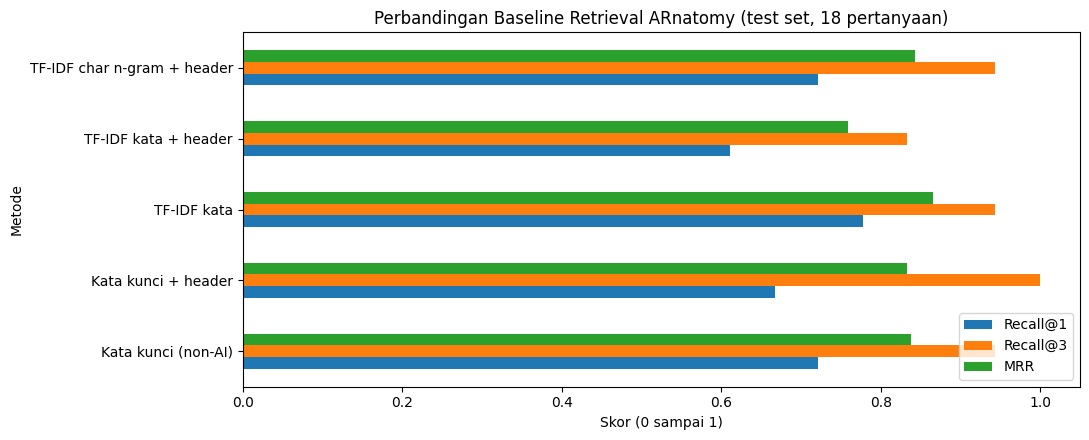

In [4]:
# Laporan akhir pada TEST set (tidak dipakai untuk memilih apa pun)
hasil_test = pd.DataFrame({n: evaluasi(r, test)[0] for n, r in kandidat.items()}).T.round(3)
hasil_semua = pd.DataFrame({n: evaluasi(r, ev)[0] for n, r in kandidat.items()}).T.round(3)
tabel = hasil_test.add_suffix(' (test)').join(hasil_semua[['MRR']].add_suffix(' (35 soal)'))
print('TABEL PERBANDINGAN BASELINE')
print(tabel.to_string())

fig, ax = plt.subplots(figsize=(11, 4.5))
hasil_test[['Recall@1', 'Recall@3', 'MRR']].plot(kind='barh', ax=ax)
ax.set_title('Perbandingan Baseline Retrieval ARnatomy (test set, 18 pertanyaan)')
ax.set_xlabel('Skor (0 sampai 1)'); ax.set_ylabel('Metode'); ax.set_xlim(0, 1.05)
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

In [5]:
# Rincian per pertanyaan untuk baseline non-AI vs konfigurasi TF-IDF terpilih
_, r_kw, top_kw = evaluasi(kandidat['Kata kunci (non-AI)'], test)
_, r_tf, top_tf = evaluasi(kandidat['TF-IDF kata + header'], test)
rinci = test[['id_q', 'pertanyaan', 'chunk_benar']].assign(
    rank_kata_kunci=r_kw, rank_tfidf=r_tf, top3_tfidf=top_tf)
print(rinci.sort_values('rank_tfidf', ascending=False).to_string(index=False))

id_q                                                       pertanyaan     chunk_benar  rank_kata_kunci  rank_tfidf      top3_tfidf
 Q03                                      Jantung punya berapa ruang?             C02               12           6 [C42, C22, C14]
 Q35                    Diafragma letaknya di sebelah mana paru-paru?     C34 C78 C15                2           4 [C31, C79, C73]
 Q10  Kenapa dinding ventrikel kiri lebih tebal dari ventrikel kanan?         C23 C22                1           4 [C05, C51, C07]
 Q08                Darah dari paru-paru masuk ke jantung lewat mana? C19 C41 C06 C44                1           2 [C73, C44, C33]
 Q23                                      Bronkitis itu penyakit apa?             C67                2           2      [C43, C67]
 Q04 Darah kotor dari seluruh tubuh masuk ke ruang jantung yang mana? C17 C37 C40 C05                2           2 [C22, C37, C49]
 Q13                Pembuluh darah paling besar di tubuh namanya apa?         C24 C

### Uji tambahan: istilah buku SMP (sinonim), pertanyaan di luar materi, dan konten draft

In [6]:
tf = kandidat['TF-IDF kata + header']
kw = kandidat['Kata kunci (non-AI)']
sinonim = ev[ev['id_q'].isin(['Q05', 'Q12', 'Q18', 'Q33'])]
_, r_s_tf, top_s = evaluasi(tf, sinonim)
_, r_s_kw, _ = evaluasi(kw, sinonim)
print('Pertanyaan dengan istilah sinonim (serambi, bilik, batang tenggorok, gelembung paru):')
print(sinonim[['pertanyaan', 'chunk_benar']].assign(rank_kata_kunci=r_s_kw, rank_tfidf=r_s_tf, top3_tfidf=top_s).to_string(index=False))

vocab = set(tf.pipe.named_steps['tfidf'].get_feature_names_out())
print('\nApakah istilah siswa ada di kosakata knowledge base?',
      {k: (k in vocab) for k in ['serambi', 'bilik', 'tenggorok', 'gelembung', 'atrium', 'ventrikel', 'trakea', 'alveolus']})

print('\nSkor tertinggi (cosine) pertanyaan di DALAM materi (test):')
skor_dalam = np.array([tf.skor(q).max() for q in test['pertanyaan']])
print(pd.Series(skor_dalam).describe().round(3).to_string())
luar = ['Apa fungsi ginjal?', 'Bagaimana cara kerja otak manusia?', 'Siapa penemu mikroskop?']
print('\nPertanyaan di LUAR materi:')
for q in luar:
    s = tf.skor(q)
    print(f'  {q:<38} skor tertinggi={s.max():.3f} -> {kb["id_chunk"].iloc[s.argmax()]}')

q_draft = 'Kenapa benda asing yang tersedak lebih sering masuk ke paru kanan?'
top = kb['id_chunk'].iloc[np.argsort(-tf.skor(q_draft))[:5]].tolist()
print(f'\nPertanyaan yang jawabannya hanya ada di chunk draft C30 -> top5: {top}',
      '| C30 terambil?', 'C30' in top)

Pertanyaan dengan istilah sinonim (serambi, bilik, batang tenggorok, gelembung paru):
                                          pertanyaan chunk_benar  rank_kata_kunci  rank_tfidf      top3_tfidf
             Serambi kanan menerima darah dari mana? C17 C37 C05                1           1 [C17, C05, C41]
Apa akibat darah tinggi terhadap bilik kiri jantung?         C51                2           1 [C51, C50, C42]
                    Berapa panjang batang tenggorok?     C11 C27                1           1           [C11]
          Gelembung paru-paru bentuknya seperti apa?     C35 C82               14          31 [C73, C72, C69]

Apakah istilah siswa ada di kosakata knowledge base? {'serambi': False, 'bilik': False, 'tenggorok': False, 'gelembung': False, 'atrium': True, 'ventrikel': True, 'trakea': True, 'alveolus': True}

Skor tertinggi (cosine) pertanyaan di DALAM materi (test):


count    18.000
mean      0.376
std       0.108
min       0.176
25%       0.290
50%       0.368
75%       0.447
max       0.572

Pertanyaan di LUAR materi:
  Apa fungsi ginjal?                     skor tertinggi=0.274 -> C49
  Bagaimana cara kerja otak manusia?     skor tertinggi=0.201 -> C18
  Siapa penemu mikroskop?                skor tertinggi=0.000 -> C01

Pertanyaan yang jawabannya hanya ada di chunk draft C30 -> top5: ['C31', 'C72', 'C79', 'C71', 'C70'] | C30 terambil? False


### Kesimpulan Soal 4: apakah baseline ML sudah lebih baik dari baseline non-AI?
**Belum terbukti.** Pada test set, TF-IDF kata punya MRR tertinggi (0,866) dibanding pencarian kata kunci (0,838), tapi selisihnya setara kurang dari satu pertanyaan (1 pertanyaan = 0,056 di test set berisi 18 soal). Kalau dihitung di seluruh 35 pertanyaan, semua metode ada di rentang MRR 0,77 sampai 0,81, jadi praktis setara. Konfigurasi yang menang di dev (TF-IDF + header) malah turun di test (MRR 0,759), tanda bahwa evaluation set masih terlalu kecil untuk memilih konfigurasi dengan yakin.

Kenapa TF-IDF belum unggul jelas: knowledge base ARnatomy kecil (81 chunk) dan istilahnya khas (emfisema, karina, pneumotoraks), sehingga pencocokan kata biasa pun sudah menemukan chunk yang benar. Kelemahan yang sama dimiliki keduanya: (1) istilah sinonim yang tidak ada di materi, misalnya "gelembung paru" untuk alveolus, gagal total (peringkat 14 dan 31), dan kata "serambi", "bilik", "batang tenggorok" tidak ada di kosakata sama sekali, hanya kebetulan tertolong kata lain di pertanyaan; (2) pertanyaan umum seperti "jantung punya berapa ruang?" kalah oleh chunk lain yang banyak mengandung kata "jantung" dan "ruang".

Tindak lanjut: tambahkan istilah buku SMP (serambi, bilik, batang tenggorok, gelembung paru) sebagai alias di header chunk, perbanyak evaluation set, lalu bandingkan dengan retrieval berbasis embedding pada Hari 3. Untuk pertanyaan di luar materi, skor tertingginya masih bisa 0,27 (ginjal), sedangkan pertanyaan di dalam materi minimal 0,18, jadi ambang skor saja belum cukup untuk menolak pertanyaan di luar materi; perlu ditambah pengecekan nama organ yang belum tersedia.

## Soal 5. Pemeriksaan Data Leakage

In [7]:
# 5a. Daftar fitur yang dipakai retriever dan kapan fitur itu tersedia
fitur = pd.DataFrame([
    ['pertanyaan', 'input siswa', 'tersedia saat prediksi', 'dipakai'],
    ['teks_bersih / teks_kb', 'isi chunk materi', 'tersedia sebelum pertanyaan masuk', 'dipakai'],
    ['nama_bagian, aspek (header)', 'metadata chunk dari data.ts', 'tersedia sebelum pertanyaan masuk', 'dipakai'],
    ['status_validasi', 'metadata chunk', 'tersedia sebelum indexing', 'hanya untuk filter draft'],
    ['chunk_benar', 'kunci jawaban evaluation set', 'baru diketahui SETELAH retrieval dinilai', 'TIDAK dipakai (hanya evaluasi)'],
], columns=['fitur', 'isi', 'ketersediaan', 'status'])
print(fitur.to_string(index=False))

                      fitur                          isi                             ketersediaan                         status
                 pertanyaan                  input siswa                   tersedia saat prediksi                        dipakai
      teks_bersih / teks_kb             isi chunk materi        tersedia sebelum pertanyaan masuk                        dipakai
nama_bagian, aspek (header)  metadata chunk dari data.ts        tersedia sebelum pertanyaan masuk                        dipakai
            status_validasi               metadata chunk                tersedia sebelum indexing       hanya untuk filter draft
                chunk_benar kunci jawaban evaluation set baru diketahui SETELAH retrieval dinilai TIDAK dipakai (hanya evaluasi)


In [8]:
# 5b. Preprocessing ada di dalam Pipeline dan hanya di-fit pada knowledge base
kosakata = set(tf.pipe.named_steps['tfidf'].get_feature_names_out())
kata_pertanyaan = set(w for q in ev['pertanyaan'] for w in normalisasi([q])[0].split())
hanya_di_pertanyaan = sorted(kata_pertanyaan - kosakata - set(STOPWORD))
print('Langkah Pipeline:', [n for n, _ in tf.pipe.steps])
print('Jumlah dokumen saat fit TF-IDF:', tf.X_dok.shape[0], '(= jumlah chunk, bukan chunk + pertanyaan)')
print('Contoh kata yang hanya ada di pertanyaan dan TIDAK masuk kosakata:', hanya_di_pertanyaan[:12])
print('Chunk draft ikut ter-index?', kb['id_chunk'].isin(['C20', 'C26', 'C30']).any())

Langkah Pipeline: ['normalisasi', 'tfidf']
Jumlah dokumen saat fit TF-IDF: 81 (= jumlah chunk, bukan chunk + pertanyaan)
Contoh kata yang hanya ada di pertanyaan dan TIDAK masuk kosakata: ['akibat', 'batang', 'bentuknya', 'bilik', 'gejalanya', 'gelembung', 'ikut', 'manusia', 'membersihkan', 'serambi', 'tenggorok', 'terhadap']
Chunk draft ikut ter-index? False


In [9]:
# 5c. Objek yang sama di dev dan test sekaligus
chunk_dev = set(c for b in dev['benar'] for c in b)
chunk_test = set(c for b in test['benar'] for c in b)
print('Chunk kunci yang muncul di dev DAN test:', sorted(chunk_dev & chunk_test))

vq = TfidfVectorizer().fit(ev['pertanyaan'])
sim_q = cosine_similarity(vq.transform(test['pertanyaan']), vq.transform(dev['pertanyaan']))
print('Kemiripan maksimum pertanyaan test terhadap pertanyaan dev:', sim_q.max().round(3))
i, j = np.unravel_index(sim_q.argmax(), sim_q.shape)
print('  pasangan paling mirip:', test['pertanyaan'].iloc[i], '<->', dev['pertanyaan'].iloc[j])

# Apakah pertanyaan disalin dari teks chunk? (cek 4-gram yang sama persis)
def ngram(t, n=4):
    w = normalisasi([t])[0].split(); return set(zip(*[w[k:] for k in range(n)]))
salin = []
for q, benar in zip(ev['pertanyaan'], ev['benar']):
    teks = ' '.join(kb.loc[kb['id_chunk'].isin(benar), 'teks_bersih'])
    salin.append(len(ngram(q) & ngram(teks)))
print('Pertanyaan yang punya 4-gram sama persis dengan chunk kuncinya:', int((np.array(salin) > 0).sum()), 'dari', len(ev))

Chunk kunci yang muncul di dev DAN test: ['C02', 'C06', 'C18', 'C32', 'C35', 'C39']
Kemiripan maksimum pertanyaan test terhadap pertanyaan dev: 0.425
  pasangan paling mirip: Kenapa dinding ventrikel kiri lebih tebal dari ventrikel kanan? <-> Kenapa paru-paru kiri lebih kecil dari yang kanan?
Pertanyaan yang punya 4-gram sama persis dengan chunk kuncinya: 5 dari 35


### Kesimpulan Soal 5
- **5a.** Retriever hanya memakai teks pertanyaan dan isi/metadata chunk yang sudah ada sebelum pertanyaan masuk. `chunk_benar` adalah kunci jawaban dan hanya dipakai untuk menghitung metrik, tidak pernah masuk ke retriever. Tidak ada fitur yang baru diketahui setelah hasil terjadi.
- **5b.** Normalisasi dan TF-IDF ada di dalam satu `Pipeline`, dan `fit` hanya dilakukan pada 81 chunk knowledge base, tidak pada pertanyaan evaluasi (terbukti kata seperti "serambi" dan "gelembung" tidak masuk kosakata). Evaluation set dipisah jadi dev dan test sebelum memilih konfigurasi, dan pemilihan konfigurasi hanya melihat dev. Chunk draft tidak ikut di-index.
- **5c.** Ada 6 chunk kunci yang muncul sebagai jawaban di dev dan test sekaligus (C02, C06, C18, C32, C35, C39), contohnya "Apa itu nodus SA?" di dev dan "Di mana letak pemacu alami jantung?" di test. Karena retriever tidak dilatih dari pertanyaan, ini tidak membocorkan jawaban secara langsung, tapi bisa membuat pemilihan konfigurasi di dev terlalu optimis. Perbaikannya: pada evaluation set berikutnya, split berdasarkan bagian organ (GroupShuffleSplit per `chunk_benar`) supaya satu bagian tidak muncul di dev dan test sekaligus. Kemiripan pertanyaan dev dan test maksimal 0,425, jadi tidak ada pertanyaan kembar.
- **Pertanyaan yang menyalin kalimat materi:** 5 dari 35 pertanyaan punya potongan 4 kata yang sama dengan chunk kuncinya (misal "tempat pertukaran oksigen dan karbon dioksida"). Ini membuat skor sedikit terlalu mudah. Perbaikannya: pertanyaan evaluasi berikutnya dikumpulkan langsung dari siswa atau guru biologi, bukan ditulis oleh tim yang sudah membaca materinya.